# Soil Moisture Prediction — Modality-Aware Transformer Pipeline

- Modality-aware Transformer with cross-attention fusion
- Shared encoder over three dynamic modality streams: SAR, optical–thermal, and temporal
- Static-context query branch with categorical embeddings
- 5-fold cross-validation with GroupKFold(station)
- Modality-specific fold-wise preprocessing
- Weighted Huber loss with cosine-annealed delta
- Quantile-based sample weighting for dry/wet tails
- Gradient-based feature importance analysis

In [ ]:
# Imports, Config, Data Loading & Feature Engineering

import os, time, copy, json, random, pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder, RobustScaler,
    QuantileTransformer, PowerTransformer
)
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import gaussian_kde
from tqdm import tqdm
import joblib


def seed_everything(seed=40):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


BASE_SEED = 40
seed_everything(BASE_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ========== Paths & Config ==========
data_dir = r".\data"
SAVE_DIR = r".\model"
BATCH_SIZE = 1024
N_FOLDS = 5
TARGET_COL = "soil_moisture"

# ========== Feature Definitions ==========
NUMERIC_COLS = [
    "angle", "VV_soil", "VH_soil",
    "s2_lag", "landsat_lag",
    "DSM", "Slope", "TWI_proxy", "Aspect_sin", "Aspect_cos",
    'Sentinel2_B2', 'Sentinel2_B3', 'Sentinel2_B4', 'Sentinel2_B5',
    'Sentinel2_B6', 'Sentinel2_B7', 'Sentinel2_B8', 'Sentinel2_B8A',
    'Sentinel2_B11', 'Sentinel2_B12',
    'Landsat_B2', 'Landsat_B3', 'Landsat_B4', 'Landsat_B5',
    'Landsat_B6', 'Landsat_B7', 'Landsat_B10',
    "NDVI_Best", "NDMI_Best", "Day_sin", "Day_cos"
]

CAT_COLS = ["BeckKG_band1", "Soil_Texture_USDA", "LandCover"]


def compute_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    bias = float(np.mean(y_pred - y_true))
    ubrmse = float(np.sqrt(np.mean(((y_pred - y_true) - bias) ** 2)))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, ubrmse, bias, r2


def make_stacking_df(df, y_true, y_pred, pred_name):
    out = pd.DataFrame()
    for col in ["station", "datetime"]:
        if col in df.columns:
            out[col] = df[col].values
    out["y_true"] = np.asarray(y_true, dtype=np.float32)
    out[pred_name] = np.asarray(y_pred, dtype=np.float32)
    cols = [c for c in ["station", "datetime"] if c in out.columns] + ["y_true", pred_name]
    return out[cols]


# ========== Load Data ==========
print("Loading datasets...")
train_df = pd.read_pickle(f"{data_dir}/train_set.pkl")  # CHANGED: this is the full CV set
test_df = pd.read_pickle(f"{data_dir}/test_set.pkl")


# ========== Urban Sample Augmentation ==========
def augment_and_synthesize_urban(
    urban_file_path, ref_train_df, target_col,
    n_real=50, n_synthetic_2021=1000, urban_code=50
):
    """Augment training data with urban (built-up) samples.
    
    1. Override 2021 LandCover=50 samples to very low moisture
    2. Sample n_real points from real urban feature dataset
    3. Graft real urban physics onto 2021 temporal backgrounds for n_synthetic_2021 samples
    """
    print(f"Urban augmentation (LandCover={urban_code})...")

    if 'datetime' in ref_train_df.columns:
        ref_train_df['datetime'] = pd.to_datetime(ref_train_df['datetime'])
        is_2021_mask = ref_train_df['datetime'].dt.year == 2021
    else:
        is_2021_mask = pd.Series(True, index=ref_train_df.index)

    mask_urban_orig = (
        (ref_train_df['LandCover'].isin([urban_code, str(urban_code)])) & is_2021_mask
    )
    orig_count = mask_urban_orig.sum()
    if orig_count > 0:
        print(f"  Overriding {orig_count} existing 2021 urban samples to [0, 0.02]")
        ref_train_df.loc[mask_urban_orig, target_col] = np.random.uniform(0.0, 0.02, size=orig_count)

    real_urban_df = pd.read_pickle(urban_file_path)
    real_urban_df['LandCover'] = urban_code
    real_urban_df = real_urban_df.loc[:, ~real_urban_df.columns.duplicated(keep='first')]
    physics_cols = [c for c in real_urban_df.columns if c in NUMERIC_COLS]

    n_sample = min(n_real, len(real_urban_df))
    base_urban_df = real_urban_df.sample(n=n_sample, replace=False).reset_index(drop=True)
    base_urban_df[target_col] = np.random.uniform(0.0, 0.02, size=len(base_urban_df))
    base_urban_df['station'] = "Real_Urban_Station"

    missing_num_cols = [c for c in NUMERIC_COLS if c not in base_urban_df.columns]
    if missing_num_cols:
        sampled_bg = ref_train_df[missing_num_cols].sample(
            n=len(base_urban_df), replace=True
        ).reset_index(drop=True)
        base_urban_df = pd.concat([base_urban_df.reset_index(drop=True), sampled_bg], axis=1)

    print(f"  Sampled {len(base_urban_df)} real urban points")

    print(f"  Synthesizing {n_synthetic_2021} urban points from 2021 backgrounds...")
    df_2021 = ref_train_df[is_2021_mask]

    if len(df_2021) > 0:
        synthetic_df = df_2021.sample(n=n_synthetic_2021, replace=True).reset_index(drop=True)
        synthetic_df['LandCover'] = urban_code
        synthetic_df[target_col] = np.random.uniform(0.0, 0.02, size=n_synthetic_2021)
        synthetic_df['station'] = "Synthetic_Urban_2021"

        sampled_physics = real_urban_df[physics_cols].sample(
            n=n_synthetic_2021, replace=True
        ).reset_index(drop=True)
        for col in physics_cols:
            synthetic_df[col] = sampled_physics[col].values
    else:
        print("  Warning: No 2021 data found, skipping synthesis")
        synthetic_df = pd.DataFrame()

    base_urban_df = base_urban_df.loc[:, ~base_urban_df.columns.duplicated(keep='first')]
    if not synthetic_df.empty:
        synthetic_df = synthetic_df.loc[:, ~synthetic_df.columns.duplicated(keep='first')]

    final_augmented = pd.concat([base_urban_df, synthetic_df], ignore_index=True)
    for col in CAT_COLS:
        if col not in final_augmented.columns:
            final_augmented[col] = urban_code if col == "LandCover" else "Missing"

    return ref_train_df, final_augmented


urban_pkl_path = r"E:.\data\buliding_points_with_features.pkl"
print(train_df["LandCover"].value_counts(dropna=False))

train_df, augmented_urban_df = augment_and_synthesize_urban(
    urban_pkl_path, train_df, TARGET_COL,
    n_real=50, n_synthetic_2021=1000, urban_code=50
)
train_df = pd.concat([train_df, augmented_urban_df], ignore_index=True)
print(f"Injected {len(augmented_urban_df)} urban samples. Training set size: {len(train_df)}")

actual_num_cols = [c for c in NUMERIC_COLS if c in train_df.columns]
actual_cat_cols = [c for c in CAT_COLS if c in train_df.columns]

# Save raw copies for CatBoost
for df in [train_df, test_df]:  # CHANGED: removed val_df
    for col in actual_cat_cols:
        df[col] = df[col].fillna("Missing").astype(str)

train_df_raw = train_df.copy()
test_df_raw = test_df.copy()

# Fill NaN with training means
train_means = train_df[actual_num_cols].mean()
for df in [train_df, test_df]:  # CHANGED: removed val_df
    df[actual_num_cols] = df[actual_num_cols].fillna(train_means)

# Label-encode categoricals
label_encoders = {}
for col in actual_cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], test_df[col]]).unique()  # CHANGED: removed val_df
    le.fit(all_values)
    for df in [train_df, test_df]:  # CHANGED: removed val_df
        df[col] = le.transform(df[col])
    label_encoders[col] = le

cat_dims = [len(label_encoders[col].classes_) for col in actual_cat_cols]

# CHANGED: train_df is already the full CV set, no merging needed
cv_df = train_df
cv_df_raw = train_df_raw
groups = cv_df["station"].astype(str).values

# Save metadata
joblib.dump(label_encoders, os.path.join(data_dir, "label_encoders.pkl"))
joblib.dump(cat_dims, os.path.join(data_dir, "cat_dims.pkl"))
joblib.dump(
    {"num_cols": actual_num_cols, "cat_cols": actual_cat_cols, "target": TARGET_COL},
    os.path.join(data_dir, "feature_names.pkl")
)

print(f"Data ready. Numeric: {len(actual_num_cols)}, Categorical: {len(actual_cat_cols)}")

Using device: cuda
Loading datasets...
LandCover
30     79907
40     36628
10     29431
20      8944
60      6332
50      3554
100     1210
90       156
Name: count, dtype: int64
Urban augmentation (LandCover=50)...
  Overriding 416 existing 2021 urban samples to [0, 0.02]
  Sampled 50 real urban points
  Synthesizing 1000 urban points from 2021 backgrounds...
Injected 1050 urban samples. Training set size: 167212
Data ready. Numeric: 31, Categorical: 3


In [2]:
# Preprocessing, Loss, Model Architecture

# ========== Modality Feature Groups ==========
SAR_FEATURES = {"VV_soil", "VH_soil", "angle"}

OPTICAL_THERMAL_FEATURES = {
    'Sentinel2_B2', 'Sentinel2_B3', 'Sentinel2_B4', 'Sentinel2_B5',
    'Sentinel2_B6', 'Sentinel2_B7', 'Sentinel2_B8', 'Sentinel2_B8A',
    'Sentinel2_B11', 'Sentinel2_B12',
    'Landsat_B2', 'Landsat_B3', 'Landsat_B4', 'Landsat_B5',
    'Landsat_B6', 'Landsat_B7', 'Landsat_B10',
    "NDVI_Best", "NDMI_Best"
}

TEMPORAL_FEATURES = {"Day_sin", "Day_cos", "s2_lag", "landsat_lag"}


def build_modality_index_map(num_col_names):
    idx_map = {"sar": [], "optical_thermal": [], "temporal": [], "static": []}
    for i, col in enumerate(num_col_names):
        if col in SAR_FEATURES:
            idx_map["sar"].append(i)
        elif col in OPTICAL_THERMAL_FEATURES:
            idx_map["optical_thermal"].append(i)
        elif col in TEMPORAL_FEATURES:
            idx_map["temporal"].append(i)
        else:
            idx_map["static"].append(i)

    dynamic_idx = sorted(idx_map["sar"] + idx_map["optical_thermal"] + idx_map["temporal"])
    dynamic_mask = np.zeros(len(num_col_names), dtype=bool)
    dynamic_mask[dynamic_idx] = True
    return idx_map, dynamic_mask, ~dynamic_mask


# ========== Fold-wise Preprocessing ==========
def fit_feature_preprocessors(X_num_train, num_col_names):
    idx_map, dynamic_mask, static_mask = build_modality_index_map(num_col_names)
    prep = {
        "idx_map": idx_map,
        "dynamic_mask": dynamic_mask,
        "static_mask": static_mask,
        "scalers": {}
    }

    # Yeo-Johnson for SAR and optical
    for modality in ["sar", "optical_thermal"]:
        idx = idx_map[modality]
        if len(idx) > 0:
            scaler = PowerTransformer(method='yeo-johnson', standardize=True)
            scaler.fit(X_num_train[:, idx])
            prep["scalers"][modality] = scaler

    # RobustScaler for temporal
    if len(idx_map["temporal"]) > 0:
        scaler = RobustScaler()
        scaler.fit(X_num_train[:, idx_map["temporal"]])
        prep["scalers"]["temporal"] = scaler

    # QuantileTransformer for static
    if static_mask.sum() > 0:
        scaler = QuantileTransformer(
            output_distribution="normal", random_state=42,
            n_quantiles=min(1000, X_num_train.shape[0])
        )
        scaler.fit(X_num_train[:, static_mask])
        prep["scalers"]["static"] = scaler

    return prep


def transform_num_features(X_num, prep):
    X_out = X_num.copy()
    idx_map = prep["idx_map"]

    for modality in ["sar", "optical_thermal", "temporal"]:
        idx = idx_map[modality]
        if len(idx) > 0:
            X_out[:, idx] = prep["scalers"][modality].transform(X_out[:, idx])

    static_mask = prep["static_mask"]
    if static_mask.sum() > 0:
        X_out[:, static_mask] = prep["scalers"]["static"].transform(X_out[:, static_mask])

    return X_out


# ========== Loss: Weighted Huber with Cosine Delta Annealing ==========
class WeightedHuberLoss(nn.Module):
    def __init__(self, start_delta=0.5, end_delta=0.02, total_epochs=150):
        super().__init__()
        self.start_delta = start_delta
        self.end_delta = end_delta
        self.total_epochs = total_epochs
        self.current_delta = start_delta

    def step(self, epoch):
        progress = min(1.0, epoch / self.total_epochs)
        self.current_delta = (
            self.end_delta
            + 0.5 * (self.start_delta - self.end_delta) * (1 + np.cos(np.pi * progress))
        )

    def forward(self, preds, targets, sample_weights=None):
        preds, targets = preds.view(-1), targets.view(-1)
        err = preds - targets
        abs_err = err.abs()
        loss = torch.where(
            abs_err <= self.current_delta,
            0.5 * err ** 2,
            self.current_delta * (abs_err - 0.5 * self.current_delta)
        )
        if sample_weights is not None:
            return (sample_weights.view(-1) * loss).mean()
        return loss.mean()


# ========== Quantile-based Sample Weighting ==========
def compute_sample_weights(y, low_q=0.10, high_q=0.90, boost=1.5, base=1.0):
    y = np.asarray(y, dtype=np.float32)
    weights = np.full_like(y, base)

    low_thresh = np.quantile(y, low_q)
    high_thresh = np.quantile(y, high_q)

    # Boost low tail
    low_mask = y < low_thresh
    if low_mask.sum() > 0:
        low_min = y[low_mask].min()
        t = (y[low_mask] - low_min) / max(low_thresh - low_min, 1e-8)
        weights[low_mask] = boost * (1 - t) + base * t

    # Boost high tail
    high_mask = y > high_thresh
    if high_mask.sum() > 0:
        high_max = y[high_mask].max()
        t = (y[high_mask] - high_thresh) / max(high_max - high_thresh, 1e-8)
        weights[high_mask] = base * (1 - t) + boost * t

    weights /= weights.mean()
    return weights


# ========== Dataset ==========
class WeightedTabularDataset(Dataset):
    def __init__(self, x_num, y, x_cat=None, weights=None):
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long) if x_cat is not None else None
        self.weights = torch.tensor(weights, dtype=torch.float32) if weights is not None else None

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xc = self.x_cat[idx] if self.x_cat is not None else torch.zeros(0, dtype=torch.long)
        w = self.weights[idx] if self.weights is not None else torch.tensor(1.0)
        return self.x_num[idx], xc, self.y[idx], w


# ========== Modality-aware Mixup ==========
def mixup_data(x_num, x_cat, y, w, idx_map, alpha=0.0):
    if alpha <= 0:
        return x_num, x_cat, y, w
    B = x_num.size(0)
    lam = np.random.beta(alpha, alpha)
    idx_shuffle = torch.randperm(B, device=x_num.device)
    x_num_mix = x_num.clone()
    x_shuffled = x_num[idx_shuffle]

    # Different mixing exponents per modality
    for mod, exp in zip(
        ["sar", "optical_thermal", "temporal", "static"], [2.0, 1.5, 1.0, 1.0]
    ):
        lam_m = lam ** exp
        idx = idx_map[mod]
        if len(idx) > 0:
            x_num_mix[:, idx] = lam_m * x_num[:, idx] + (1 - lam_m) * x_shuffled[:, idx]

    y_mix = lam * y + (1 - lam) * y[idx_shuffle]
    w_mix = lam * w + (1 - lam) * w[idx_shuffle]
    return x_num_mix, x_cat, y_mix, w_mix


# ========== Model Components ==========
class MLPFeatureTokenizer(nn.Module):
    def __init__(self, num_features, d_model):
        super().__init__()
        self.feature_scales = nn.Parameter(torch.ones(num_features) * 0.5)
        self.num_projs = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, d_model // 2), nn.GELU(),
                nn.Linear(d_model // 2, d_model), nn.LayerNorm(d_model)
            )
            for _ in range(num_features)
        ])
        self.pos_embedding = nn.Parameter(torch.randn(1, num_features, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

    def forward(self, x):
        B = x.size(0)
        scaled = x * F.softplus(self.feature_scales).unsqueeze(0)
        tokens = torch.cat(
            [proj(scaled[:, i:i+1]).unsqueeze(1) for i, proj in enumerate(self.num_projs)],
            dim=1
        )
        tokens = tokens + self.pos_embedding
        cls = self.cls_token.expand(B, -1, -1)
        return torch.cat([cls, tokens], dim=1)


class PreNormTransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model), nn.Dropout(dropout),
        )
        self.drop1 = nn.Dropout(dropout)

    def forward(self, x):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h)
        x = x + self.drop1(h)
        x = x + self.ffn(self.norm2(x))
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            PreNormTransformerLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class CrossAttentionFusion(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.3):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, query, key_value):
        attn_out, _ = self.cross_attn(query, key_value, key_value)
        h = query + self.drop(attn_out)
        h = h + self.ffn(self.norm(h))
        return h.squeeze(1)


class EnhancedSoilTransformer_v4(nn.Module):
    def __init__(
        self, num_col_names, cat_col_names, cat_dims_list,
        d_model=168, nhead=8, num_layers_per_stream=2,
        dim_feedforward=512, dropout=0.25, static_dropout=0.45,
    ):
        super().__init__()
        self.num_col_names = num_col_names
        self.cat_col_names = cat_col_names
        self.idx_map, self.dynamic_mask, self.static_mask = build_modality_index_map(num_col_names)
        self.dynamic_idx = sorted(
            self.idx_map["sar"] + self.idx_map["optical_thermal"] + self.idx_map["temporal"]
        )
        self.static_idx = self.idx_map["static"]

        # Categorical embeddings
        self.has_cat = len(cat_dims_list) > 0
        self.embeddings = nn.ModuleList()
        self.emb_total_dim = 0
        if self.has_cat:
            for d in cat_dims_list:
                ed = int(min(16, round(np.sqrt(d)) + 1))
                self.embeddings.append(nn.Embedding(d, ed))
                self.emb_total_dim += ed

        self.has_sar = len(self.idx_map["sar"]) > 0
        self.has_opt = len(self.idx_map["optical_thermal"]) > 0
        self.has_temp = len(self.idx_map["temporal"]) > 0

        # Per-modality tokenizers + modality embeddings
        if self.has_sar:
            self.sar_tokenizer = MLPFeatureTokenizer(len(self.idx_map["sar"]), d_model)
            self.modality_emb_sar = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        if self.has_opt:
            self.opt_tokenizer = MLPFeatureTokenizer(len(self.idx_map["optical_thermal"]), d_model)
            self.modality_emb_opt = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        if self.has_temp:
            self.temp_tokenizer = MLPFeatureTokenizer(len(self.idx_map["temporal"]), d_model)
            self.modality_emb_temp = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        self.shared_dynamic_encoder = TransformerEncoder(
            d_model, nhead, dim_feedforward, dropout, num_layers=num_layers_per_stream
        )

        # Static branch
        static_out_dim = len(self.static_idx) + self.emb_total_dim
        self.static_proj = nn.Sequential(
            nn.Linear(static_out_dim, d_model), nn.LayerNorm(d_model),
            nn.GELU(), nn.Dropout(dropout)
        )
        self.static_dropout = nn.Dropout(static_dropout)

        # Cross-attention fusion + prediction head
        self.fusion = CrossAttentionFusion(d_model, nhead, dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(d_model // 4, 1),
        )

    def encode_dynamic(self, x_num):
        token_blocks = []
        if self.has_sar:
            token_blocks.append(
                self.sar_tokenizer(x_num[:, self.idx_map["sar"]]) + self.modality_emb_sar
            )
        if self.has_opt:
            token_blocks.append(
                self.opt_tokenizer(x_num[:, self.idx_map["optical_thermal"]]) + self.modality_emb_opt
            )
        if self.has_temp:
            token_blocks.append(
                self.temp_tokenizer(x_num[:, self.idx_map["temporal"]]) + self.modality_emb_temp
            )
        return self.shared_dynamic_encoder(torch.cat(token_blocks, dim=1))

    def forward(self, x_num, x_cat):
        encoded_dynamic = self.encode_dynamic(x_num)

        static_feats = [x_num[:, self.static_idx]]
        if self.has_cat and x_cat.shape[1] > 0:
            static_feats.extend(emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings))

        x_static = self.static_dropout(torch.cat(static_feats, dim=1))
        x_static_proj = self.static_proj(x_static).unsqueeze(1)

        fused = self.fusion(x_static_proj, encoded_dynamic)
        return self.head(fused).squeeze(1)


# ========== Training Helpers ==========
def build_transformer(**kwargs):
    return EnhancedSoilTransformer_v4(
        num_col_names=actual_num_cols,
        cat_col_names=actual_cat_cols,
        cat_dims_list=cat_dims,
        **kwargs
    ).to(device)


def compute_val_score(y_true, y_pred):
    """Composite validation score: RMSE + slope/intercept penalties."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    yt_mean, yp_mean = y_true.mean(), y_pred.mean()
    var_true = np.mean((y_true - yt_mean) ** 2)
    cov = np.mean((y_true - yt_mean) * (y_pred - yp_mean))
    slope = cov / (var_true + 1e-8)
    intercept = yp_mean - slope * yt_mean
    score = rmse + 0.03 * abs(slope - 1.0) + 0.20 * abs(intercept)
    return float(score), rmse, float(slope), float(intercept)


def eval_loss_and_preds(model, loader, criterion):
    model.eval()
    total_loss, preds_all, y_all = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            x_num, x_cat, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
            preds = model(x_num, x_cat)
            total_loss += F.mse_loss(preds, y).item() * x_num.size(0)
            preds_all.append(preds.cpu().numpy())
            y_all.append(y.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(preds_all), np.concatenate(y_all)


print("Model architecture and utilities ready.")

Model architecture and utilities ready.


In [3]:
# Cross-Validation Training

TF_MODEL_PARAMS = {
    "d_model": 168,
    "nhead": 8,
    "num_layers_per_stream": 2,
    "dim_feedforward": 512,
    "dropout": 0.25,
}

TF_OPTIMIZER_PARAMS = {"lr": 2e-4, "weight_decay": 0.02}
EPOCHS_TF = 150
PATIENCE_TF = 20
BATCH_SIZE_TF = 1024
MIXUP_ALPHA_TF = 0

# Prepare arrays
X_num_all_raw = cv_df[actual_num_cols].values.astype(np.float32)
X_num_test_raw = test_df[actual_num_cols].values.astype(np.float32)
X_cat_all = cv_df[actual_cat_cols].values.astype(np.int64)
X_cat_test_tf = test_df[actual_cat_cols].values.astype(np.int64)
y_all_tf = cv_df[TARGET_COL].values.astype(np.float32)
y_test_tf = test_df[TARGET_COL].values.astype(np.float32)

oof_preds_tf = np.zeros(len(cv_df), dtype=np.float32)
test_preds_tf = np.zeros(len(test_df), dtype=np.float32)

gkf = GroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=BASE_SEED)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_num_all_raw, y_all_tf, groups=groups), 1):
    print(f"\n--- Fold {fold}/{N_FOLDS} ---")

    # Fold-specific preprocessing
    X_num_tr_raw, X_num_va_raw = X_num_all_raw[tr_idx], X_num_all_raw[va_idx]
    preprocessors = fit_feature_preprocessors(X_num_tr_raw, actual_num_cols)

    X_num_tr = transform_num_features(X_num_tr_raw, preprocessors).astype(np.float32)
    X_num_va = transform_num_features(X_num_va_raw, preprocessors).astype(np.float32)
    X_num_test_fold = transform_num_features(X_num_test_raw, preprocessors).astype(np.float32)

    joblib.dump(preprocessors, os.path.join(SAVE_DIR, f"transformer_v4_fold_{fold}.pkl"))

    y_tr = y_all_tf[tr_idx]
    sample_weights_tr = compute_sample_weights(y_tr, low_q=0.10, high_q=0.90, boost=1.5, base=1.0)

    train_loader = DataLoader(
        WeightedTabularDataset(X_num_tr, y_tr, x_cat=X_cat_all[tr_idx], weights=sample_weights_tr),
        batch_size=BATCH_SIZE_TF, shuffle=True, num_workers=0, drop_last=True
    )
    val_loader = DataLoader(
        WeightedTabularDataset(X_num_va, y_all_tf[va_idx], x_cat=X_cat_all[va_idx]),
        batch_size=BATCH_SIZE_TF, shuffle=False, num_workers=0
    )
    test_loader_tf = DataLoader(
        WeightedTabularDataset(X_num_test_fold, y_test_tf, x_cat=X_cat_test_tf),
        batch_size=BATCH_SIZE_TF, shuffle=False, num_workers=0
    )

    model = build_transformer(**TF_MODEL_PARAMS)
    train_criterion = WeightedHuberLoss(start_delta=0.5, end_delta=0.02, total_epochs=EPOCHS_TF)
    optimizer = optim.AdamW(model.parameters(), **TF_OPTIMIZER_PARAMS)

    # Warmup + cosine decay LR schedule
    warmup_epochs = 10
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, EPOCHS_TF - warmup_epochs)
        return 0.1 + 0.9 * 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_val_rmse = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    pbar = tqdm(range(EPOCHS_TF), desc=f"Fold {fold}", leave=False)
    for epoch in pbar:
        train_criterion.step(epoch)
        model.train()
        train_loss_sum = 0.0

        for x_num, x_cat, y, w in train_loader:
            x_num, x_cat = x_num.to(device), x_cat.to(device)
            y, w = y.to(device), w.to(device)

            x_num_m, x_cat_m, y_m, w_m = mixup_data(
                x_num, x_cat, y, w, idx_map=model.idx_map, alpha=MIXUP_ALPHA_TF
            )

            optimizer.zero_grad()
            loss = train_criterion(model(x_num_m, x_cat_m), y_m, sample_weights=w_m)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss_sum += loss.item() * x_num.size(0)

        scheduler.step()

        val_mse, val_preds, val_true = eval_loss_and_preds(model, val_loader, nn.MSELoss())
        val_rmse = float(np.sqrt(mean_squared_error(val_true, val_preds)))

        pbar.set_postfix({
            "train": f"{train_loss_sum / len(train_loader.dataset):.4f}",
            "val_rmse": f"{val_rmse:.4f}",
            "best": f"{best_val_rmse:.4f}",
            "delta": f"{train_criterion.current_delta:.3f}",
            "lr": f"{optimizer.param_groups[0]['lr']:.1e}"
        })

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            patience_counter = 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE_TF:
                print(f"  Early stopping at epoch {epoch + 1}")
                break

    model.load_state_dict(best_weights)

    torch.save({
        "model_state_dict": best_weights,
        "idx_map": model.idx_map,
        "dynamic_idx": model.dynamic_idx,
        "static_idx": model.static_idx,
        "model_params": TF_MODEL_PARAMS,
        "num_col_names": actual_num_cols,
        "cat_col_names": actual_cat_cols,
        "cat_dims": cat_dims,
    }, os.path.join(SAVE_DIR, f"transformer_v4_fold_{fold}.pth"))

    _, val_preds_best, val_true_best = eval_loss_and_preds(model, val_loader, nn.MSELoss())
    _, test_preds_fold, _ = eval_loss_and_preds(model, test_loader_tf, nn.MSELoss())

    oof_preds_tf[va_idx] = val_preds_best
    test_preds_tf += test_preds_fold / N_FOLDS

    fold_rmse, fold_ubrmse, fold_bias, fold_r2 = compute_metrics(val_true_best, val_preds_best)
    print(
        f"  Fold {fold} | RMSE={fold_rmse:.4f} | ubRMSE={fold_ubrmse:.4f} | "
        f"Bias={fold_bias:.4f} | R²={fold_r2:.4f}"
    )

# Overall results
cv_m = compute_metrics(y_all_tf, oof_preds_tf)
test_m = compute_metrics(y_test_tf, test_preds_tf)

print("\n=== Transformer V4 Overall ===")
print(f"OOF  | RMSE={cv_m[0]:.4f} | ubRMSE={cv_m[1]:.4f} | Bias={cv_m[2]:.4f} | R²={cv_m[3]:.4f}")
print(f"Test | RMSE={test_m[0]:.4f} | ubRMSE={test_m[1]:.4f} | Bias={test_m[2]:.4f} | R²={test_m[3]:.4f}")

# Save stacking predictions
make_stacking_df(cv_df, y_all_tf, oof_preds_tf, "pred_transformer_v4").to_csv(
    os.path.join(SAVE_DIR, "stacking_oof_transformer_v4.csv"), index=False
)
make_stacking_df(test_df, y_test_tf, test_preds_tf, "pred_transformer_v4").to_csv(
    os.path.join(SAVE_DIR, "stacking_test_transformer_v4.csv"), index=False
)


--- Fold 1/5 ---


  Early stopping at epoch 35
  Fold 1 | RMSE=0.0837 | ubRMSE=0.0836 | Bias=-0.0019 | R²=0.3761

--- Fold 2/5 ---


  Early stopping at epoch 28
  Fold 2 | RMSE=0.0886 | ubRMSE=0.0886 | Bias=-0.0026 | R²=0.3475

--- Fold 3/5 ---


  Early stopping at epoch 55
  Fold 3 | RMSE=0.0893 | ubRMSE=0.0890 | Bias=0.0070 | R²=0.2756

--- Fold 4/5 ---


  Early stopping at epoch 42
  Fold 4 | RMSE=0.0811 | ubRMSE=0.0811 | Bias=0.0010 | R²=0.4721

--- Fold 5/5 ---


  Early stopping at epoch 46
  Fold 5 | RMSE=0.0840 | ubRMSE=0.0839 | Bias=0.0014 | R²=0.4422

=== Transformer V4 Overall ===
OOF  | RMSE=0.0854 | ubRMSE=0.0854 | Bias=0.0011 | R²=0.3895
Test | RMSE=0.0870 | ubRMSE=0.0866 | Bias=-0.0091 | R²=0.4026


In [4]:
# Gradient-based Feature Importance Analysis

n_samples = 100
sample_df = test_df.head(n_samples).copy()
x_num_full = torch.from_numpy(sample_df[actual_num_cols].values.astype(np.float32)).to(device)
x_cat_full = torch.from_numpy(sample_df[actual_cat_cols].values.astype(np.int64)).to(device)

# Load first available checkpoint for index metadata
first_ckpt = None
for fold in range(1, 6):
    model_path = os.path.join(SAVE_DIR, f"transformer_v4_fold_{fold}.pth")
    if os.path.exists(model_path):
        first_ckpt = torch.load(model_path, map_location=device)
        break
if first_ckpt is None:
    raise FileNotFoundError("No checkpoint found in SAVE_DIR.")

dynamic_idx = np.array(first_ckpt.get("dynamic_idx", sorted(
    first_ckpt.get("idx_map", {}).get("sar", []) +
    first_ckpt.get("idx_map", {}).get("optical", []) +
    first_ckpt.get("idx_map", {}).get("temporal", [])
)))
static_idx = np.array(first_ckpt.get("static_idx", first_ckpt.get("idx_map", {}).get("static", [])))

# Accumulate gradient importance across folds
importance_dynamic = np.zeros(len(dynamic_idx))
importance_static = np.zeros(len(static_idx))
importance_cat = np.zeros(len(actual_cat_cols))
processed_folds = 0

embedding_outputs = []
def embedding_forward_hook(module, input, output):
    output.retain_grad()
    embedding_outputs.append(output)

for fold in range(1, 6):
    model_path = os.path.join(SAVE_DIR, f"transformer_v4_fold_{fold}.pth")
    if not os.path.exists(model_path):
        continue

    print(f"  Processing Fold {fold}...")
    ckpt = torch.load(model_path, map_location=device)
    model = build_transformer()
    model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    model.to(device).eval()

    hook_handles = [emb.register_forward_hook(embedding_forward_hook) for emb in model.embeddings]
    grad_dynamic_list, grad_static_list, grad_cat_list = [], [], []

    for si in range(n_samples):
        if (si + 1) % 25 == 0:
            print(f"    Sample {si + 1}/{n_samples}")

        embedding_outputs.clear()
        x_num_s = x_num_full[si:si+1].clone().requires_grad_(True)
        x_cat_s = x_cat_full[si:si+1].long()

        # Gradient w.r.t. dynamic features (detach static)
        try:
            x_copy = x_num_s.clone()
            x_copy[:, static_idx] = x_num_s[:, static_idx].detach()
            out = model(x_copy, x_cat_s).mean()
            if x_num_s.grad is not None:
                x_num_s.grad.zero_()
            model.zero_grad()
            out.backward(retain_graph=True)
            grad_dynamic_list.append(x_num_s.grad.clone().detach().cpu().numpy()[0])

            if len(embedding_outputs) == len(actual_cat_cols):
                cat_imp = [
                    np.abs(eo.grad.cpu().numpy()).mean() if eo.grad is not None else 0.0
                    for eo in embedding_outputs
                ]
                grad_cat_list.append(cat_imp)
            else:
                grad_cat_list.append(np.zeros(len(actual_cat_cols)))
        except Exception:
            grad_dynamic_list.append(np.zeros(len(actual_num_cols)))
            grad_cat_list.append(np.zeros(len(actual_cat_cols)))

        # Gradient w.r.t. static features (detach dynamic)
        try:
            x_copy = x_num_s.clone()
            x_copy[:, dynamic_idx] = x_num_s[:, dynamic_idx].detach()
            out = model(x_copy, x_cat_s).mean()
            if x_num_s.grad is not None:
                x_num_s.grad.zero_()
            out.backward(retain_graph=True)
            grad_static_list.append(x_num_s.grad.clone().detach().cpu().numpy()[0])
        except Exception:
            grad_static_list.append(np.zeros(len(actual_num_cols)))

        if (si + 1) % 20 == 0:
            torch.cuda.empty_cache()

    for h in hook_handles:
        h.remove()

    importance_dynamic += np.abs(np.array(grad_dynamic_list)[:, dynamic_idx]).mean(axis=0)
    importance_static += np.abs(np.array(grad_static_list)[:, static_idx]).mean(axis=0)
    importance_cat += np.array(grad_cat_list).mean(axis=0)
    processed_folds += 1

importance_dynamic /= processed_folds
importance_static /= processed_folds
importance_cat /= processed_folds

# Build importance DataFrame
results = []
for idx, imp in zip(dynamic_idx, importance_dynamic):
    results.append({'Feature': actual_num_cols[idx], 'Importance': float(imp), 'Stream': 'Dynamic'})
for idx, imp in zip(static_idx, importance_static):
    results.append({'Feature': actual_num_cols[idx], 'Importance': float(imp), 'Stream': 'Static'})
for feat_name, imp in zip(actual_cat_cols, importance_cat):
    results.append({'Feature': feat_name, 'Importance': float(imp), 'Stream': 'Static'})

importance_df = pd.DataFrame(results).sort_values('Importance', ascending=False).reset_index(drop=True)
print("Feature importance analysis complete.")
importance_df

  Processing Fold 1...
    Sample 25/100
    Sample 50/100
    Sample 75/100
    Sample 100/100
  Processing Fold 2...
    Sample 25/100
    Sample 50/100
    Sample 75/100
    Sample 100/100
  Processing Fold 3...
    Sample 25/100
    Sample 50/100
    Sample 75/100
    Sample 100/100
  Processing Fold 4...
    Sample 25/100
    Sample 50/100
    Sample 75/100
    Sample 100/100
  Processing Fold 5...
    Sample 25/100
    Sample 50/100
    Sample 75/100
    Sample 100/100
Feature importance analysis complete.


,Feature,Importance,Stream
0,Landsat_B3,0.045729,Dynamic
1,Landsat_B6,0.039882,Dynamic
2,Landsat_B10,0.038029,Dynamic
3,Landsat_B7,0.035837,Dynamic
4,Day_sin,0.026944,Dynamic
5,Sentinel2_B12,0.024591,Dynamic
6,Sentinel2_B3,0.024378,Dynamic
7,Sentinel2_B2,0.021697,Dynamic
8,NDVI_Best,0.018309,Dynamic
9,Landsat_B4,0.016357,Dynamic


Dynamic mean importance: 0.016608
Static mean importance:  0.004559
Ratio (Dynamic / Static): 3.64x


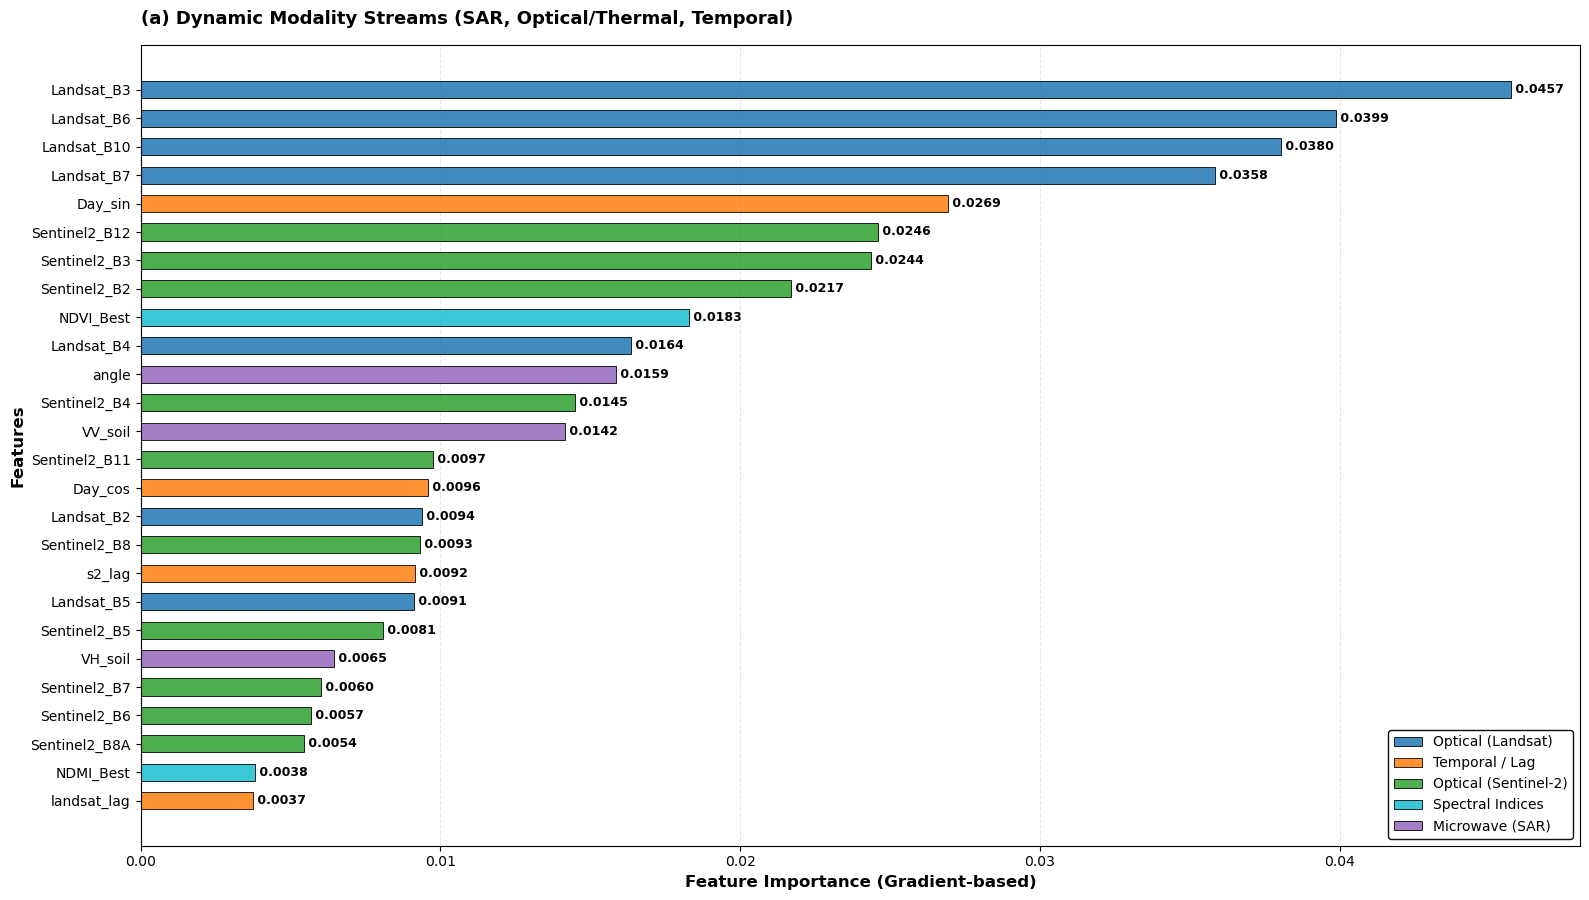

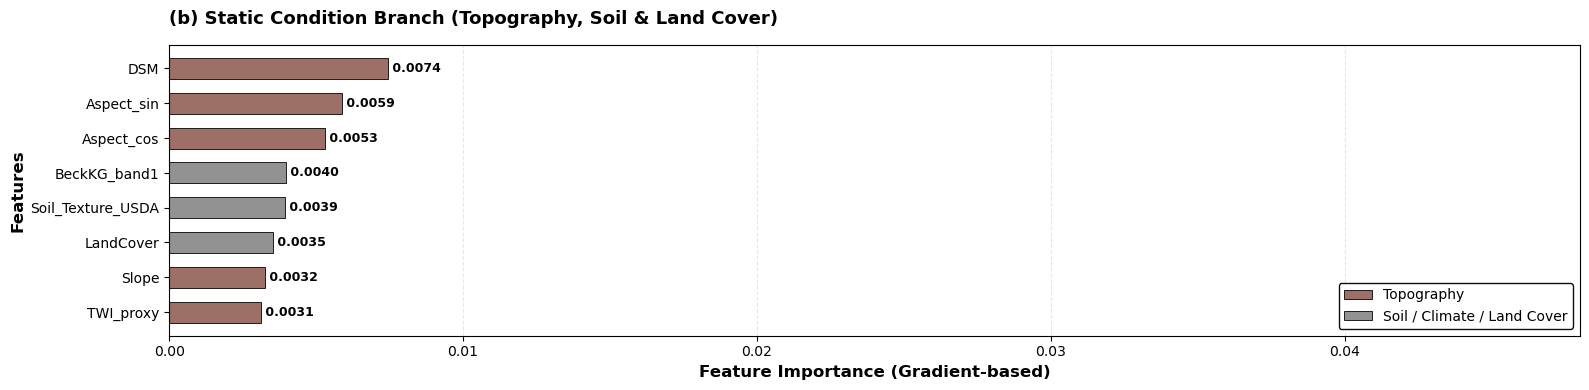

In [5]:
# Feature Importance Visualization

FEATURE_PHYSICAL_GROUPS = {
    "SAR":        {"feats": ['angle', 'VV_soil', 'VH_soil'],               "color": "#9467bd", "label": "Microwave (SAR)"},
    "Thermal":    {"feats": ['LST_final'],                                  "color": "#d62728", "label": "Thermal (LST)"},
    "Sentinel-2": {"feats": ['Sentinel2_B2', 'Sentinel2_B3', 'Sentinel2_B4', 'Sentinel2_B5',
                             'Sentinel2_B6', 'Sentinel2_B7', 'Sentinel2_B8', 'Sentinel2_B8A',
                             'Sentinel2_B11', 'Sentinel2_B12'],
                   "color": "#2ca02c", "label": "Optical (Sentinel-2)"},
    "Landsat":    {"feats": ['Landsat_B2', 'Landsat_B3', 'Landsat_B4', 'Landsat_B5',
                             'Landsat_B6', 'Landsat_B7', 'Landsat_B10'],
                   "color": "#1f77b4", "label": "Optical (Landsat)"},
    "Indices":    {"feats": ['NDVI_Best', 'NDMI_Best'],                     "color": "#17becf", "label": "Spectral Indices"},
    "Temporal":   {"feats": ['s2_lag', 'landsat_lag', 'Day_sin', 'Day_cos'],"color": "#ff7f0e", "label": "Temporal / Lag"},
    "Topography": {"feats": ['DSM', 'Slope', 'TWI_proxy', 'Aspect_sin', 'Aspect_cos'],
                   "color": "#8c564b", "label": "Topography"},
    "Environment":{"feats": ['BeckKG_band1', 'Soil_Texture_USDA', 'LandCover'],
                   "color": "#7f7f7f", "label": "Soil / Climate / Land Cover"}
}

feature_to_color, feature_to_group = {}, {}
for group_name, info in FEATURE_PHYSICAL_GROUPS.items():
    for feat in info["feats"]:
        feature_to_color[feat] = info["color"]
        feature_to_group[feat] = group_name

BAR_HEIGHT = 0.6
HEIGHT_PER_FEATURE = 0.35
x_limit = importance_df['Importance'].max() * 1.05


def plot_importance_bar(df_stream, title):
    df_plot = df_stream.copy()
    df_plot['color'] = df_plot['Feature'].map(lambda x: feature_to_color.get(x, '#cccccc'))
    df_plot = df_plot.sort_values('Importance', ascending=True)

    fig_h = max(len(df_plot) * HEIGHT_PER_FEATURE, 4)
    fig, ax = plt.subplots(figsize=(16, fig_h))
    ax.barh(
        df_plot['Feature'], df_plot['Importance'], height=BAR_HEIGHT,
        color=df_plot['color'], edgecolor='black', linewidth=0.7, alpha=0.85
    )
    for i, (_, row) in enumerate(df_plot.iterrows()):
        ax.text(row['Importance'], i, f" {row['Importance']:.4f}",
                va='center', ha='left', fontsize=9, fontweight='bold')

    ax.set_xlim(0, x_limit)
    ax.set_xlabel('Feature Importance (Gradient-based)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Features', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15, loc='left')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

    # Legend from physical groups present
    legend_elements, seen = [], set()
    for feat in df_plot['Feature'][::-1]:
        g = feature_to_group.get(feat)
        if g and g not in seen:
            gi = FEATURE_PHYSICAL_GROUPS[g]
            legend_elements.append(
                Patch(facecolor=gi['color'], edgecolor='black', linewidth=0.7, label=gi['label'], alpha=0.85)
            )
            seen.add(g)
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.95, edgecolor='black')
    plt.tight_layout()
    return fig


df_dyn = importance_df[importance_df['Stream'] == 'Dynamic']
df_sta = importance_df[importance_df['Stream'] == 'Static']

fig1 = plot_importance_bar(df_dyn, '(a) Dynamic Modality Streams (SAR, Optical/Thermal, Temporal)')
fig2 = plot_importance_bar(df_sta, '(b) Static Condition Branch (Topography, Soil & Land Cover)')

ratio = df_dyn['Importance'].mean() / df_sta['Importance'].mean()
print(f"Dynamic mean importance: {df_dyn['Importance'].mean():.6f}")
print(f"Static mean importance:  {df_sta['Importance'].mean():.6f}")
print(f"Ratio (Dynamic / Static): {ratio:.2f}x")

In [ ]:
# Prediction Scatter Plots (OOF & Test)

def plot_prediction_scatter(y_true, y_pred, title="Transformer", figsize=(8, 8)):
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()

    r2 = r2_score(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ubrmse = np.sqrt(np.maximum(0, rmse**2 - bias**2))

    # KDE density coloring
    xy = np.vstack([y_true, y_pred])
    z = gaussian_kde(xy)(xy)
    order = z.argsort()
    x, y, z = y_true[order], y_pred[order], z[order]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')

    sc = ax.scatter(x, y, c=z, s=10, cmap='viridis', edgecolors='none', alpha=0.9)

    axis_max = max(y_true.max(), y_pred.max()) * 1.05
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.plot([0, axis_max], [0, axis_max], 'r--', linewidth=1.5, zorder=3)

    ax.set_xlabel('Actual soil moisture (m³/m³)', fontsize=12)
    ax.set_ylabel('Predicted soil moisture (m³/m³)', fontsize=12)
    ax.set_title(title, fontsize=13)

    textstr = f'R²: {r2:.4f}\nBias: {bias:.4f}\nRMSE: {rmse:.4f}\nubRMSE: {ubrmse:.4f}'
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top',
            bbox=dict(boxstyle='square', facecolor='white', edgecolor='gray', alpha=0.75))

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.08)
    cax.set_facecolor('none')
    fig.colorbar(sc, cax=cax).set_label('Density (KDE)', fontsize=10)

    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout()
    return fig, (r2, bias, rmse, ubrmse)


# Load stacking CSVs
oof_df = pd.read_csv(os.path.join(SAVE_DIR, "stacking_oof_transformer_v4.csv"))
test_scatter_df = pd.read_csv(os.path.join(SAVE_DIR, "stacking_test_transformer_v4.csv"))

fig_oof, metrics_oof = plot_prediction_scatter(
    oof_df["y_true"].values, oof_df["pred_transformer_v4"].values,
    title="Transformer (OOF)"
)
fig_test, metrics_test = plot_prediction_scatter(
    test_scatter_df["y_true"].values, test_scatter_df["pred_transformer_v4"].values,
    title="Transformer (Test)"
)
plt.show()

print(f"OOF  — R²: {metrics_oof[0]:.4f}, Bias: {metrics_oof[1]:.4f}, "
      f"RMSE: {metrics_oof[2]:.4f}, ubRMSE: {metrics_oof[3]:.4f}")
print(f"Test — R²: {metrics_test[0]:.4f}, Bias: {metrics_test[1]:.4f}, "
      f"RMSE: {metrics_test[2]:.4f}, ubRMSE: {metrics_test[3]:.4f}")